# The Chosen Dataset
- We chose a dataset from the Stack Overflow Developer Survey, which contains information about developers worldwide such as experience, education, job roles, technologies used, and salaries. It is used to analyze trends in the software engineering field and understand factors affecting developers’ careers.

- Source: https://survey.stackoverflow.co/


# Task 1: Exploratory Data Analysis & Visualization

- Imports

In [56]:
import numpy as np
import pandas as pd
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
import skfuzzy as fuzz

from skfuzzy import control as ctrl

- Read data

In [57]:
df = pd.read_csv('stackoverflow_survey.csv')
# df = df.sample(n=10000, random_state=42)

C:\Users\kareem\AppData\Local\Temp\ipykernel_28156\3893294044.py:1: DtypeWarning: Columns (0: ResponseId, 1: DevEnvHaveEntry, 2: SOTagsHaveEntry, 3: SOTagsWant Entry, 4: CommPlatformHaveEntr, 5: CommPlatformWantEntr, 6: AIAgentOrchestration, 7: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('stackoverflow_survey.csv')


In [58]:
df.sample(20)

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,Industry,AIThreat,NewRole,ToolCountWork,ToolCountPersonal,Country,Currency,CompTotal,LanguageChoice,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,LanguagesHaveEntry,LanguagesWantEntry,DevEnvsChoice,DevEnvsHaveWorkedWith,DevEnvsWantToWorkWith,DevEnvsAdmired,DevEnvHaveEntry,DevEnvWantEntry,SOTagsHaveWorkedWith,SOTagsWantToWorkWith,SOTagsAdmired,SOTagsHaveEntry,SOTagsWant Entry,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,CommPlatformHaveWorkedWith,CommPlatformWantToWorkWith,CommPlatformAdmired,CommPlatformHaveEntr,CommPlatformWantEntr,AIModelsChoice,AIModelsHaveWorkedWith,AIModelsWantToWorkWith,AIModelsAdmired,AIModelsHaveEntry,AIModelsWantEntry,SOAccount,SOVisitFreq,SODuration,SOPartFreq,SO_Dev_Content,SOComm,SOFriction,AISelect,AISent,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
35777,35773,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...",None of the above,11.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools req...",AI CodeGen tools or AI-enabled apps;Technical ...,15.0,AI/ML engineer,NaN,NaN,NaN,No,Work,8.0,1.0,5.0,7.0,9.0,6.0,3.0,4.0,2.0,10.0,NaN,Software Development,No,I have neither consider or transitioned into a...,10.0,4.0,United States of America,USD United States dollar,235000.0,Yes,Go;Python;SQL;TypeScript,Elixir;Python;Rust;SQL,Python;SQL,NaN,NaN,Yes,Claude Code;Cursor;Jupyter Notebook/JupyterLab...,Claude Code;Cursor;Neovim,Claude Code;Cursor;Neovim,NaN,NaN,Large Language Model;Amazon Bedrock;Pydantic;R...,Large Language Model;Amazon Bedrock;Pydantic;R...,Large Language Model;Amazon Bedrock;Pydantic;R...,NaN,NaN,MacOS;iOS;iPadOS,MacOS;Ubuntu;iOS;Linux (non-WSL);iPadOS,Airtable;GitHub;Google Colab;Jira;Linear;Markd...,GitHub;Linear;Markdown File;Notion;Obsidian,GitHub;Linear;Markdown File;Notion;Obsidian,Stack Overflow;Discord;Reddit;Hacker News;GitH...,Stack Overflow;Discord;Hacker News;GitHub (pub...,Stack Overflow;Discord;Hacker News;GitHub (pub...,"Circle, Beehiiv","Circle, Beehiiv",Yes,Anthropic: Claude Sonnet;openAI GPT (chatbot m...,Anthropic: Claude Sonnet;DeepSeek (R- Reasonin...,Anthropic: Claude Sonnet;openAI GPT (chatbot m...,Anthropic Claude Opus,Anthropic Claude Opus,Yes,A few times per week,Between 10 and 15 years,"Infrequently, less than once per year",Message Boards;Job board;Day-in-the-life profi...,"Yes, somewhat","Rarely, almost never","Yes, I use AI tools daily",Very favorable,AI agents have increased my productivity.;AI a...,NaN,NaN,Integrating AI agents with my existing tools a...,I have concerns about the security and privacy...,I am concerned about the accuracy of the infor...,My company's IT and/or InfoSec teams have stri...,ChromaDB;Milvus;Pinecone,"LangGraph, internal frameworks, MCP",LangGraph,NaN,Langfuse,NaN,ChatGPT;Claude Code;Cody,NaN,When I don’t trust AI’s answers;When I want to...,"Critical thinking, abstract problem design, tr...",235000.0,NaN
9623,9619,I am a developer by profession,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,7.0,"Yes, I am not

In [59]:
df.dtypes

ResponseId              object
MainBranch                 str
Age                        str
EdLevel                    str
Employment                 str
                        ...   
AIAgentExtWrite            str
AIHuman                    str
AIOpen                     str
ConvertedCompYearly    float64
JobSat                 float64
Length: 98, dtype: object

In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49196 entries, 0 to 49195
Data columns (total 98 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ResponseId                          49195 non-null  object 
 1   MainBranch                          49190 non-null  str    
 2   Age                                 49190 non-null  str    
 3   EdLevel                             48148 non-null  str    
 4   Employment                          48338 non-null  str    
 5   EmploymentAddl                      44874 non-null  str    
 6   WorkExp                             42892 non-null  float64
 7   LearnCodeChoose                     46857 non-null  str    
 8   LearnCode                           33556 non-null  str    
 9   LearnCodeAI                         45200 non-null  str    
 10  AILearnHow                          28256 non-null  str    
 11  YearsCode                           43041 non-null  

In [61]:
df.describe()

,WorkExp,YearsCode,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,ToolCountWork,ToolCountPersonal,CompTotal,ConvertedCompYearly,JobSat
count,42892.000000,43041.000000,35974.000000,35974.000000,35974.000000,35974.000000,35974.000000,35974.000000,35974.000000,35974.000000,35974.000000,35974.000000,27610.000000,25581.000000,2.486500e+04,2.394600e+04,26669.000000
mean,13.367551,16.571037,7.867265,4.104214,4.110246,5.677990,4.119308,5.225913,6.477512,4.370879,4.431506,9.854200,17.735168,8.545757,2.234287e+70,1.017630e+05,7.201845
std,10.800199,11.787691,2.397408,2.275852,2.329564,2.397806,2.437932,2.801046,2.331380,2.357080,2.620773,1.975599,269.815015,44.665602,3.523167e+72,4.617665e+05,1.997209
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000e+00,1.000000e+00,0.000000
25%,5.000000,8.000000,7.000000,2.000000,2.000000,4.000000,2.000000,3.000000,5.000000,2.000000,2.000000,10.000000,4.000000,3.000000,5.500000e+04,3.817100e+04,6.000000
50%,10.000000,14.000000,9.000000,4.000000,4.000000,6.000000,4.000000,5.000000,7.000000,4.000000,4.000000,10.000000,6.000000,5.000000,1.050000e+05,7.532000e+04,8.000000
75%,20.000000,24.000000,9.000000,6.000000,6.000000,8.000000,6.000000,8.000000,8.000000,6.000000,7.000000,10.000000,10.000000,7.000000,2.400000e+05,1.205980e+05,8.000000
max,100.000000,100.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,10000.000000,1000.000000,5.555556e+74,5.000000e+07,10.000000


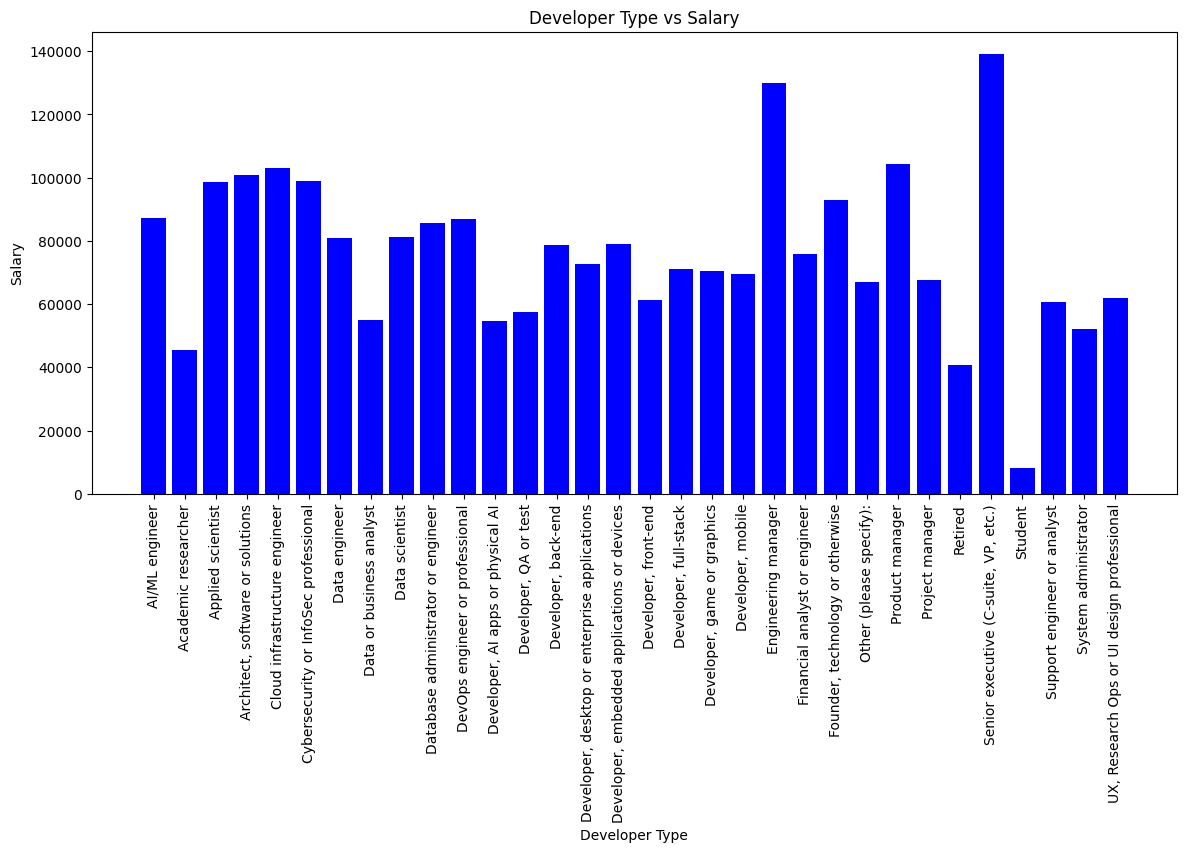

In [62]:
plt.figure(figsize=(14,6))
salaryByType = df.groupby('DevType')['ConvertedCompYearly'].median()
plt.bar(salaryByType.index, salaryByType.values, color="blue")
plt.title("Developer Type vs Salary")
plt.xlabel("Developer Type")
plt.xticks(rotation=90)
plt.ylabel("Salary")
plt.show()

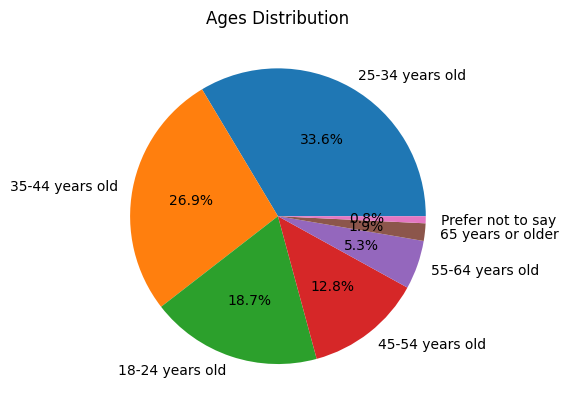

In [63]:
plt.pie(df["Age"].value_counts(), labels=df["Age"].value_counts().index, autopct="%1.1f%%")
plt.title("Ages Distribution")
plt.show()

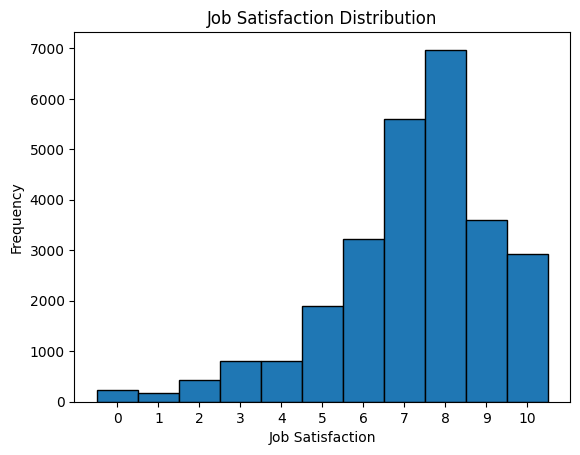

In [64]:
plt.hist(df["JobSat"], bins=np.arange(-0.5, 11.5, 1), edgecolor='black')
plt.title("Job Satisfaction Distribution")
plt.xlabel("Job Satisfaction")
plt.ylabel("Frequency")
plt.xticks(range(11))
plt.show()

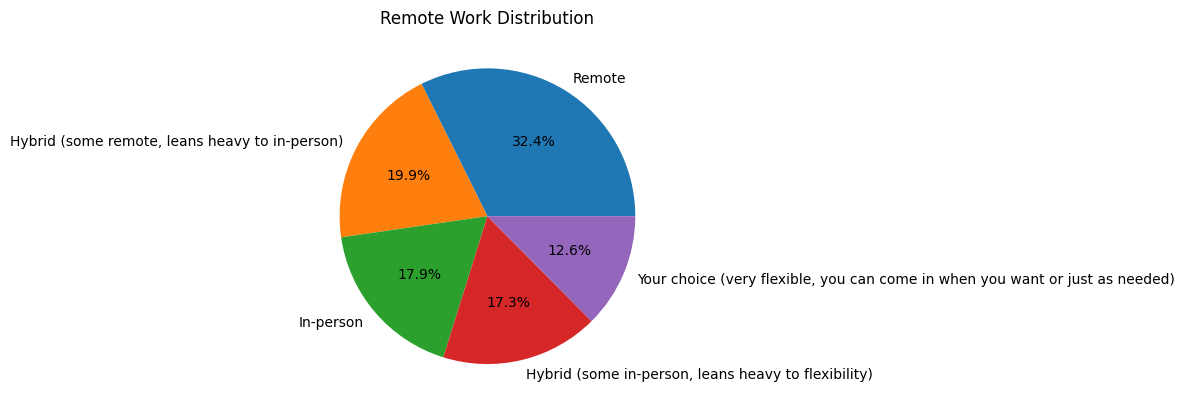

In [65]:
plt.pie(df["RemoteWork"].value_counts(), labels=df["RemoteWork"].value_counts().index, autopct="%1.1f%%")
plt.title("Remote Work Distribution")
plt.show()

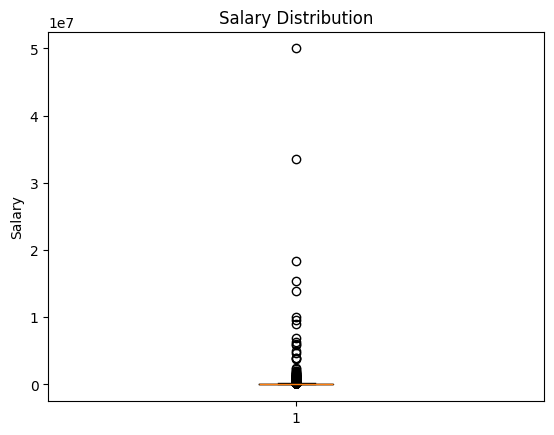

In [66]:
plt.boxplot(df["ConvertedCompYearly"].dropna())
plt.title("Salary Distribution")
plt.ylabel("Salary")
plt.show()

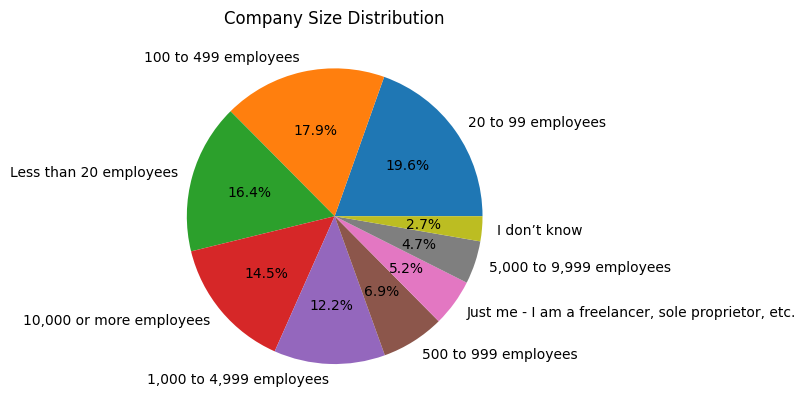

In [67]:
plt.pie(df["OrgSize"].value_counts(), labels=df["OrgSize"].value_counts().index, autopct="%1.1f%%")
plt.title("Company Size Distribution")
plt.show()

# Task 2: Data Preprocessing 

- Select most important features

In [68]:
df = df[['Age', 'EdLevel', 'Employment', 'WorkExp',
        'LearnCode', 'YearsCode', 'DevType', 'OrgSize',
        'RemoteWork', 'Industry', 'AIThreat', 'NewRole',
        'AISelect', 'AISent', 'Country', 
        'LanguageAdmired', 'ConvertedCompYearly', 'JobSat']]

# LearnCode, YearsCode, LanguageAdmired ==> Tech Score (Bonus)
# AIThreat, newRule, aiSelect, AiSent ==> Ai Score (Bonus)

### Remove duplicate rows

In [69]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

2923
0


### Handle missing values

In [70]:
df.isnull().sum()

Age                        1
EdLevel                  174
Employment                 8
WorkExp                 4310
LearnCode              12759
YearsCode               3249
DevType                 2609
OrgSize                12100
RemoteWork             12498
Industry               12632
AIThreat               10196
NewRole                10747
AISelect               12554
AISent                 12807
Country                10837
LanguageAdmired        22804
ConvertedCompYearly    22327
JobSat                 19604
dtype: int64

In [71]:
df.dropna(subset=['LanguageAdmired', 'AISelect', 'AISent', 'AIThreat', 'NewRole', 'ConvertedCompYearly', 'YearsCode', 'LearnCode', 'JobSat'], axis=0, inplace=True)

In [72]:
# Numerical Columns (Median)
num_cols = ['WorkExp']

for col in num_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Categories Columns (Mod)
cat_cols = ['OrgSize', 'RemoteWork', 'Industry' , 'WorkExp',  'EdLevel']

for col in cat_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)


In [73]:
df.isnull().sum()

Age                    0
EdLevel                0
Employment             0
WorkExp                0
LearnCode              0
YearsCode              0
DevType                0
OrgSize                0
RemoteWork             0
Industry               0
AIThreat               0
NewRole                0
AISelect               0
AISent                 0
Country                0
LanguageAdmired        0
ConvertedCompYearly    0
JobSat                 0
dtype: int64

### Detecting and treating outliers

IQR outliers in ConvertedCompYearly: 434


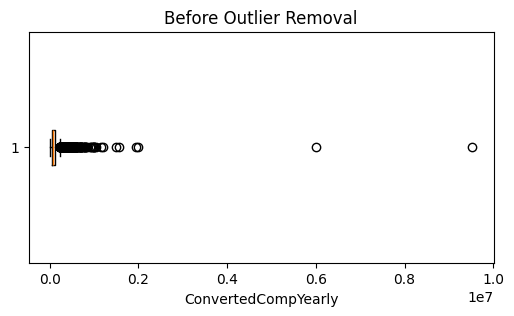

Remaining rows after trimming: 9752


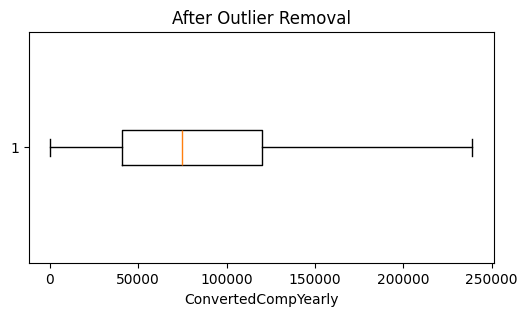

In [74]:
col = "ConvertedCompYearly"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

print(f'IQR outliers in {col}: {len(outliers_iqr)}')

# Before plot
plt.figure(figsize=(6, 3))
plt.boxplot(df[col], vert=False)
plt.title('Before Outlier Removal')
plt.xlabel(col)
plt.show()

# Remove outliers properly

df[col] = df[col].clip(lower_bound, upper_bound)

print(f"Remaining rows after trimming: {len(df)}")

# After plot
plt.figure(figsize=(6, 3))
plt.boxplot(df[col], vert=False)
plt.title('After Outlier Removal')
plt.xlabel(col)
plt.show()

### Encoding categorical features

- Label Encoding

In [75]:
for col in ['Age', 'EdLevel', 'OrgSize', 'AIThreat', 'RemoteWork']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

- One-Hot Encoding

In [76]:
learncode_encoded = df['LearnCode'].str.get_dummies(sep=';')
learncode_encoded.columns = [f"LearnCode_{col.strip()}" for col in learncode_encoded.columns]
df = pd.concat([df.drop(columns=['LearnCode']), learncode_encoded], axis=1)

one_hot_cols = ['Employment', 'DevType', 'Industry', 'NewRole', 'AISelect', 'AISent', 'Country', 'LanguageAdmired']
df = pd.get_dummies(df, columns=one_hot_cols)

### Feature scaling

- Standardization (z-score)

In [77]:
for col in ['WorkExp', 'YearsCode', 'ConvertedCompYearly']:
    std_scaler = MinMaxScaler()
    df[col] = std_scaler.fit_transform(df[[col]])

### Dimensionality Reduction

- AI Score

In [78]:
print([col for col in df.columns if "AISelect" in col])
print([col for col in df.columns if "AISent" in col])
print([col for col in df.columns if "NewRole" in col])

["AISelect_No, and I don't plan to", 'AISelect_No, but I plan to soon', 'AISelect_Yes, I use AI tools daily', 'AISelect_Yes, I use AI tools monthly or infrequently', 'AISelect_Yes, I use AI tools weekly']
['AISent_Favorable', 'AISent_Indifferent', 'AISent_Unfavorable', 'AISent_Unsure', 'AISent_Very favorable', 'AISent_Very unfavorable']
['NewRole_I have neither consider or transitioned into a new career or industry', 'NewRole_I have somewhat considered changing my career and/or the industry I work in', 'NewRole_I have strongly considered changing my career and/or the industry I work in', 'NewRole_I have transitioned into a new career and/or industry involuntarily', 'NewRole_I have transitioned into a new career and/or industry voluntarily']


In [79]:
ai_select_cols = [col for col in df.columns if col.startswith('AISelect_')]
ai_sent_cols = [col for col in df.columns if col.startswith('AISent_')]
new_role_cols = [col for col in df.columns if col.startswith('NewRole_')]

ai_cols = ai_select_cols + ai_sent_cols + new_role_cols + ['AIThreat']

ai_features = df[ai_cols]

pca = PCA(n_components=1)
df['AIScore'] = pca.fit_transform(ai_features).ravel()

df.drop(columns=ai_cols, inplace=True)

- Tech Score

In [80]:
print([col for col in df.columns if "LearnCode_" in col])
print([col for col in df.columns if "LanguageAdmired_" in col])

['LearnCode_AI CodeGen tools or AI-enabled apps', 'LearnCode_Blogs or podcasts', 'LearnCode_Books / Physical media', 'LearnCode_Coding Bootcamp', 'LearnCode_Colleague or on-the-job training', 'LearnCode_Games or coding challenges', 'LearnCode_Online Courses or Certification (includes all media types)', 'LearnCode_Other (please specify):', 'LearnCode_Other online resources (e.g. standard search, forum, online community)', 'LearnCode_School (i.e., University, College, etc)', 'LearnCode_Stack Overflow or Stack Exchange', 'LearnCode_Technical documentation (is generated for/by the tool or system)', 'LearnCode_Videos (not associated with specific online course or certification)']
['LanguageAdmired_Ada', 'LanguageAdmired_Ada;Assembly', 'LanguageAdmired_Ada;Assembly;Bash/Shell (all shells);C++;Go;JavaScript;PowerShell;Python;Rust;TypeScript', 'LanguageAdmired_Ada;Assembly;Bash/Shell (all shells);C;C#;C++;COBOL;Dart;Delphi;Elixir;Erlang;F#;Fortran;GDScript;Go;Groovy;HTML/CSS;Java;JavaScript;Ko

In [81]:
learncode_cols = [col for col in df.columns if col.startswith('LearnCode_')]
language_cols = [col for col in df.columns if col.startswith('LanguageAdmired_')]

tech_cols = learncode_cols + ['YearsCode'] + language_cols

tech_features = df[tech_cols]

pca = PCA(n_components=1)
df['TechScore'] = pca.fit_transform(tech_features).ravel()

df.drop(columns=tech_cols, inplace=True)

# Task 3: K-Medoid Clustering

In [82]:
data=df.values

In [83]:
inertias = []
silhouette_scores = []
k_range = range(2, 20)

for k in k_range:
    model = KMedoids(n_clusters=k, metric="manhattan", init="random", random_state=42)
    model.fit(data)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(data, model.labels_))

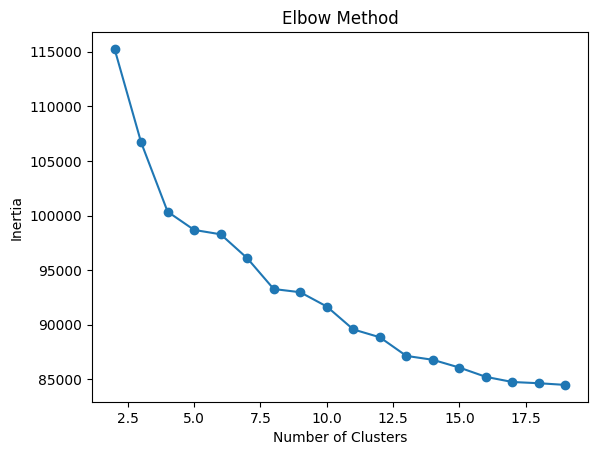

In [84]:
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

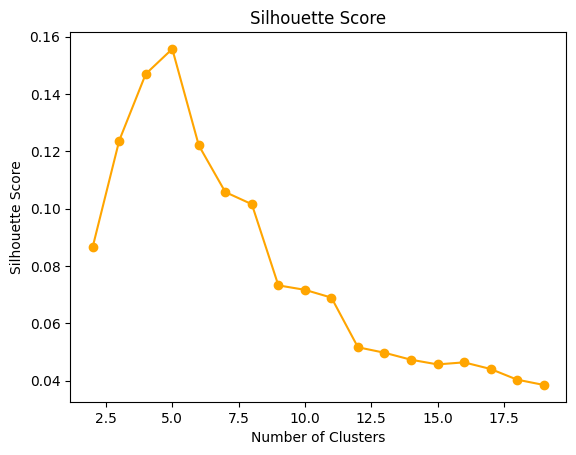

In [85]:
plt.plot(k_range, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [86]:
best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print("best k:", best_k)

best k: 5


In [87]:
Kmedoids_model = KMedoids(n_clusters=best_k, metric="manhattan", init="random")
Kmedoids_model.fit(data)

,n_clusters,5
,metric,'manhattan'
,method,'alternate'
,init,'random'
,max_iter,300
,random_state,None


In [88]:
centers = Kmedoids_model.medoid_indices_
print("centers: ", centers)

centers:  [4755 7481 4353 6929 7973]


In [89]:
df['Cluster'] = Kmedoids_model.labels_

# Task 4: Hierarchical Clustering

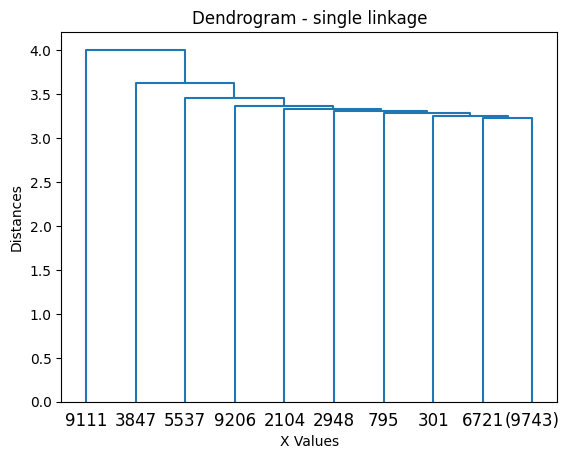

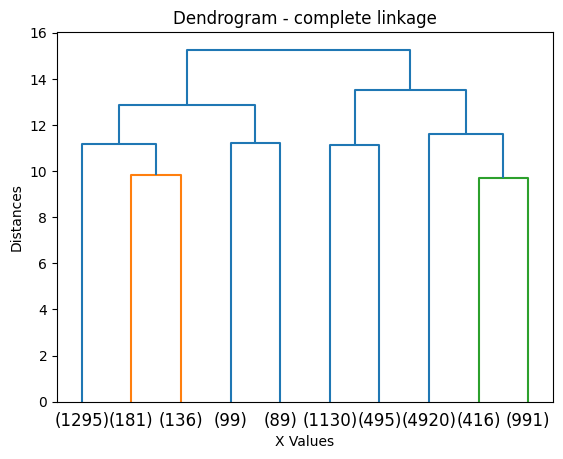

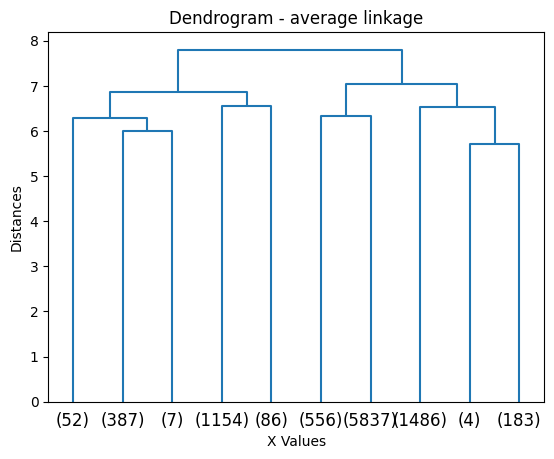

In [90]:
for method in ['single', 'complete', 'average']:
    dendrogram = sch.dendrogram(sch.linkage(data, method), truncate_mode='lastp', p=10)
    plt.title(f'Dendrogram - {method} linkage')
    plt.xlabel('X Values')
    plt.ylabel('Distances')
    plt.show()

In [91]:
inertias = []
silhouette_scores = []
k_range = range(2, 20)

for k in k_range:
    model = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = model.fit_predict(data)
    silhouette_scores.append(silhouette_score(data, labels))

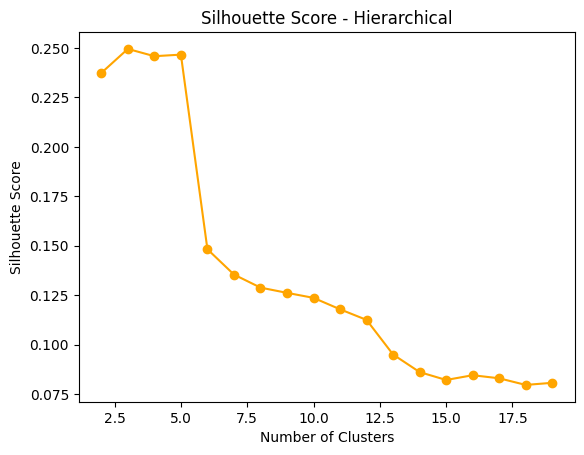

Best K: 3


In [92]:
plt.plot(k_range, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Score - Hierarchical')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print("Best K:", best_k)

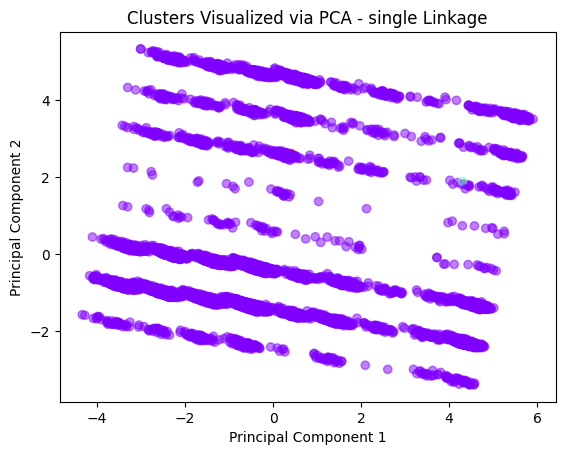

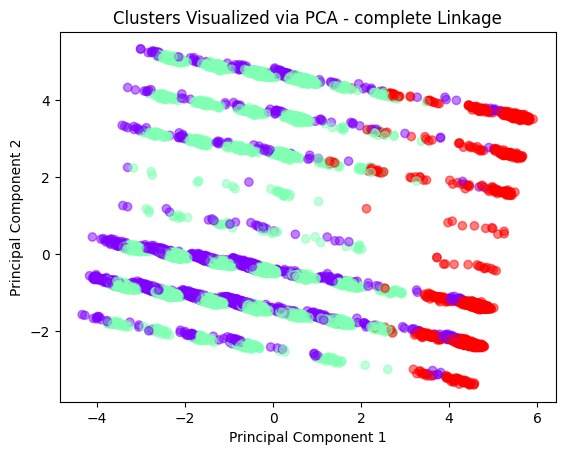

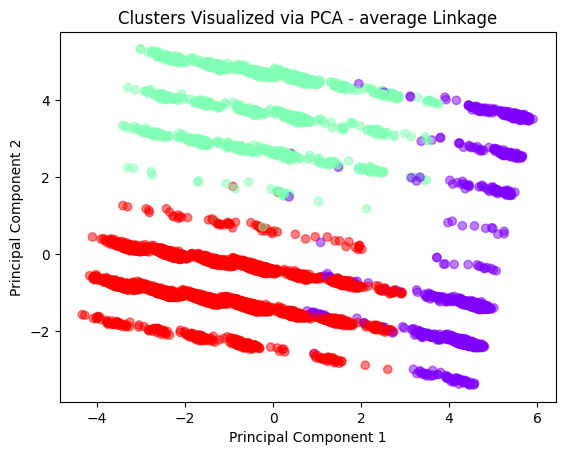

In [93]:
Hcluster = {}
Hlabels = {}

for method in ['single', 'complete', 'average']:
    Hcluster[method] = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage=method)
    Hlabels[method] = Hcluster[method].fit_predict(data)
    pca_2d = PCA(n_components=2)
    data_2d = pca_2d.fit_transform(data)

    plt.scatter(data_2d[:,0], data_2d[:,1], c=Hlabels[method], cmap='rainbow', alpha=0.5)
    plt.title(f'Clusters Visualized via PCA - {method} Linkage')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()


# Task 5: Fuzzy Logic Inference System


Correlation with JobSat:
JobSat                 1.000000
Cluster                0.137930
ConvertedCompYearly    0.108018
WorkExp                0.104147
AIScore                0.031020
TechScore              0.007444
Name: JobSat, dtype: float64


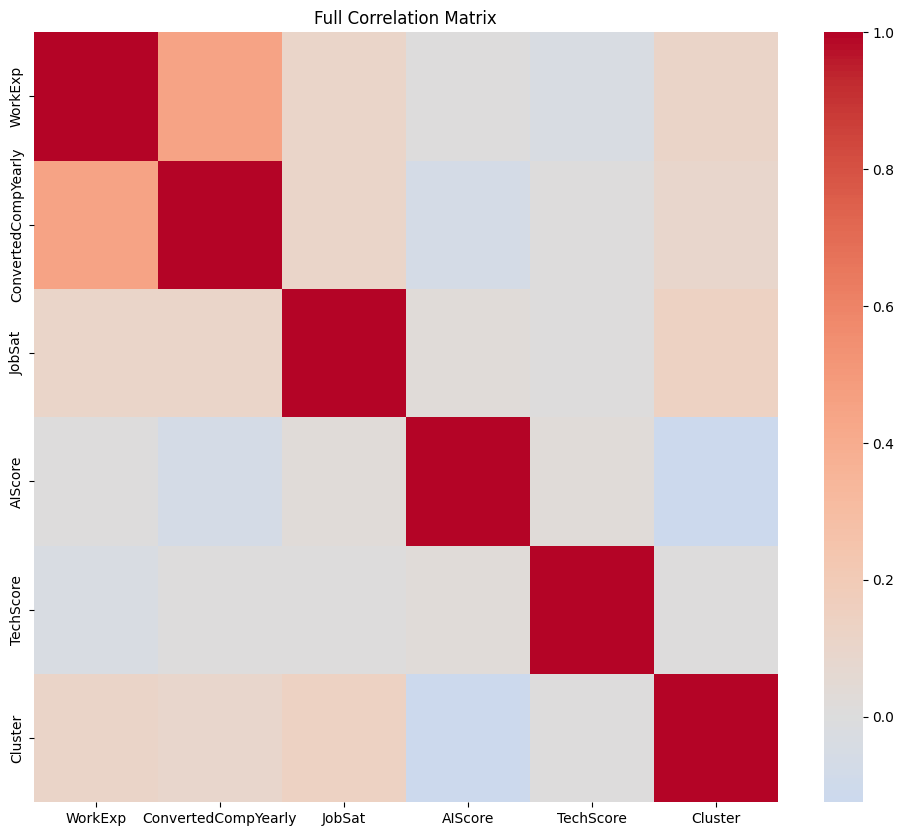

Feature importance (absolute correlation):
JobSat                 1.000000
Cluster                0.168710
WorkExp                0.096223
ConvertedCompYearly    0.086762
AIScore                0.042284
TechScore              0.005847
Name: JobSat, dtype: float64


In [94]:
df_corr = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = df_corr.corr(method='spearman')
job_corr = corr_matrix['JobSat'].sort_values(ascending=False)

print("Correlation with JobSat:")
print(job_corr)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Full Correlation Matrix")
plt.show()

importance = df_corr.corr()['JobSat'].abs().sort_values(ascending=False)

print("Feature importance (absolute correlation):")
print(importance)

- Antecedents

In [95]:
pd.set_option('display.max_columns', None)
df.sample(20)

,Age,EdLevel,WorkExp,OrgSize,RemoteWork,ConvertedCompYearly,JobSat,Employment_Employed,Employment_I prefer not to say,"Employment_Independent contractor, freelancer, or self-employed",Employment_Not employed,Employment_Student,DevType_AI/ML engineer,DevType_Academic researcher,DevType_Applied scientist,"DevType_Architect, software or solutions",DevType_Cloud infrastructure engineer,DevType_Cybersecurity or InfoSec professional,DevType_Data engineer,DevType_Data or business analyst,DevType_Data scientist,DevType_Database administrator or engineer,DevType_DevOps engineer or professional,"DevType_Developer, AI apps or physical AI","DevType_Developer, QA or test","DevType_Developer, back-end","DevType_Developer, desktop or enterprise applications","DevType_Developer, embedded applications or devices","DevType_Developer, front-end","DevType_Developer, full-stack","DevType_Developer, game or graphics","DevType_Developer, mobile",DevType_Engineering manager,DevType_Financial analyst or engineer,"DevType_Founder, technology or otherwise",DevType_Other (please specify):,DevType_Product manager,DevType_Project manager,"DevType_Senior executive (C-suite, VP, etc.)",DevType_Student,DevType_Support engineer or analyst,DevType_System administrator,"DevType_UX, Research Ops or UI design professional",Industry_Banking/Financial Services,Industry_Computer Systems Design and Services,Industry_Energy,Industry_Fintech,Industry_Government,Industry_Healthcare,Industry_Higher Education,Industry_Insurance,"Industry_Internet, Telecomm or Information Services",Industry_Manufacturing,Industry_Media & Advertising Services,Industry_Other:,Industry_Retail and Consumer Services,Industry_Software Development,"Industry_Transportation, or Supply Chain",Country_Afghanistan,Country_Albania,Country_Algeria,Country_Andorra,Country_Argentina,Country_Armenia,Country_Australia,Country_Austria,Country_Azerbaijan,Country_Bahrain,Country_Bangladesh,Country_Belarus,Country_Belgium,Country_Benin,Country_Bhutan,Country_Bolivia,Country_Bosnia and Herzegovina,Country_Brazil,Country_Bulgaria,Country_Cambodia,Country_Cameroon,Country_Canada,Country_Chile,Country_China,Country_Colombia,Country_Costa Rica,Country_Croatia,Country_Cuba,Country_Cyprus,Country_Czech Republic,Country_Côte d'Ivoire,Country_Denmark,Country_Dominican Republic,Country_Ecuador,Country_Egypt,Country_El Salvador,Country_Estonia,Country_Ethiopia,Country_Finland,Country_France,Country_Georgia,Country_Germany,Country_Ghana,Country_Greece,Country_Guatemala,Country_Guyana,Country_Haiti,Country_Honduras,Country_Hong Kong (S.A.R.),Country_Hungary,Country_Iceland,Country_India,Country_Indonesia,"Country_Iran, Islamic Republic of...",Country_Ireland,Country_Isle of Man,Country_Israel,Country_Italy,Country_Japan,Country_Jordan,Country_Kazakhstan,Country_Kenya,Country_Kosovo,Country_Kuwait,Country_Kyrgyzstan,Country_Latvia,Country_Lebanon,Country_Libyan Arab Jamahiriya,Country_Lithuania,Country_Luxembourg,Country_Madagascar,Country_Malawi,Country_Malaysia,Country_Maldives,Country_Mali,Country_Malta,Country_Mauritius,Country_Mexico,Country_Moldova,Country_Mongolia,Country_Montenegro,Country_Morocco,Country_Mozambique,Country_Namibia,Country_Nepal,Country_Netherlands,Country_New Zealand,Country_Nicaragua,Country_Nigeria,Country_Nomadic,Country_North Korea,Country_Norway,Country_Pakistan,Country_Panama,Country_Paraguay,Country_Peru,Country_Philippines,Country_Poland,Country_Portugal,Country_Republic of Korea,Country_Republic of Moldova,Country_Republic of North Macedonia,Country_Romania,Country_Russian Federation,Country_Rwanda,Country_Saudi Arabia,Country_Senegal,Country_Serbia,Country_Singapore,Country_Slovakia,Country_Slovenia,Country_Somalia,Country_South Africa,Country_South Korea,Country_Spain,Country_Sri Lanka,Country_Swaziland,Country_Sweden,Country_Switzerland,Country_Syrian Arab Republic,Country_Taiwan,Country_Thailand,Country_Togo,Country_Trinidad and Tobago,Country_Tunisia,Country_Turkey,Country_Uganda,Countr

In [96]:
df['JobSat'].describe()

count    9752.000000
mean        7.176682
std         1.947116
min         0.000000
25%         6.000000
50%         8.000000
75%         8.000000
max        10.000000
Name: JobSat, dtype: float64

In [97]:
ConvertedCompYearly = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'ConvertedCompYearly')
WorkExp = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'WorkExp')
RemoteWork = ctrl.Antecedent(np.arange(0, 5, 1), 'RemoteWork')
TechScore = ctrl.Antecedent(np.arange(-1.5, 1.51, 0.01), 'TechScore')
AIScore = ctrl.Antecedent(np.arange(-1.1, 1.01, 0.01), 'AIScore')
dev_profile = ctrl.Antecedent(np.arange(0, 5, 1), 'dev_profile')

- Consequent

In [98]:
JobSat = ctrl.Consequent(np.arange(1, 11, 1), 'JobSat')

- Auto-membership Function Population

In [99]:
ConvertedCompYearly.automf(3)
WorkExp.automf(3)
RemoteWork.automf(3)
TechScore.automf(3)
AIScore.automf(3)
dev_profile.automf(5)

# print(ConvertedCompYearly.terms)
# print(WorkExp.terms)
# print(RemoteWork.terms)
# print(TechScore.terms)
# print(AIScore.terms)
# print(dev_profile.terms)

- Custom Labels for the Output

In [100]:
sat_labels = [
    'Very unsatisfied',
    'Slightly unsatisfied',
    'Neutral',
    'Slightly satisfied',
    'Very satisfied'
]
JobSat.automf(names=sat_labels)

In [101]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

- Visualization

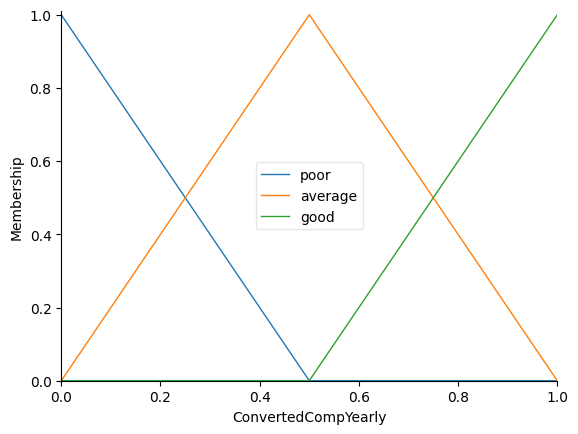

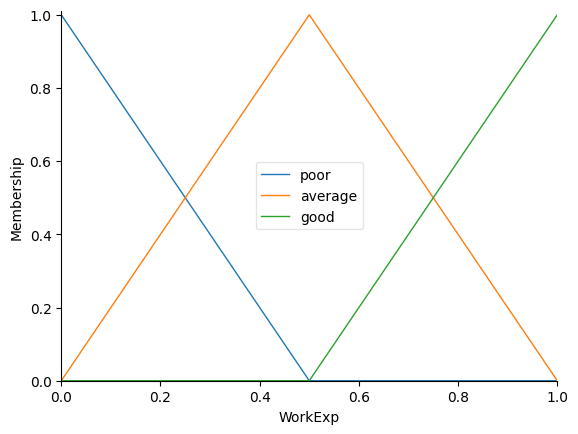

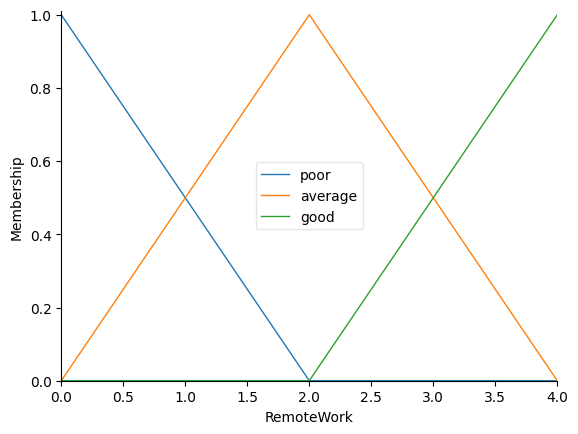

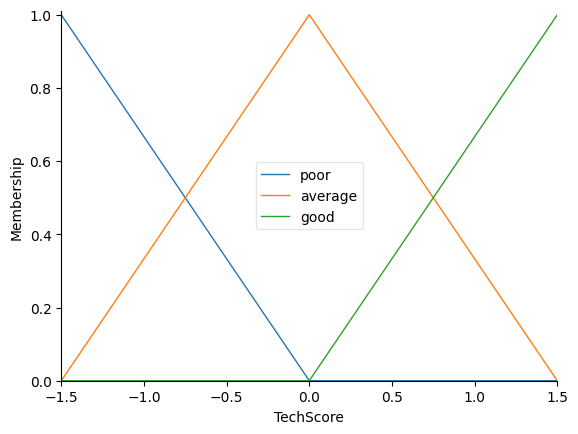

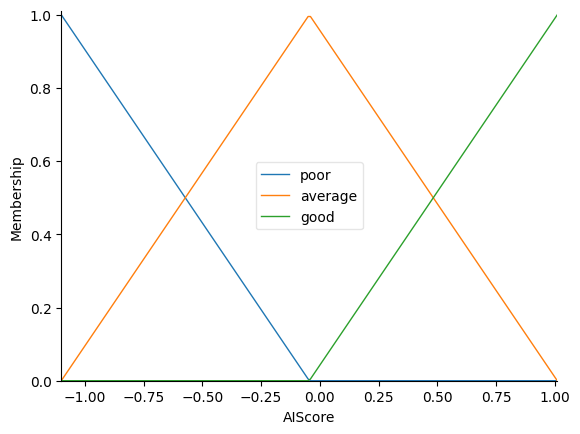

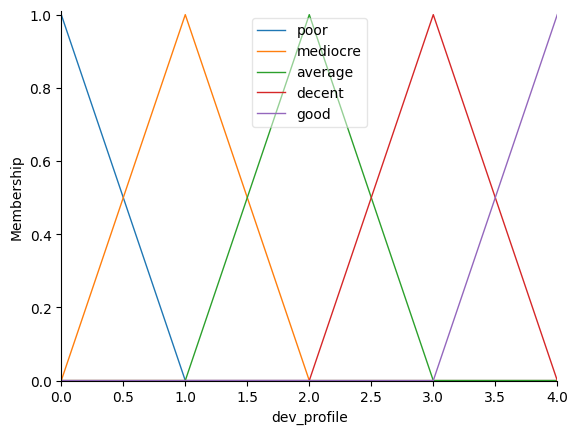

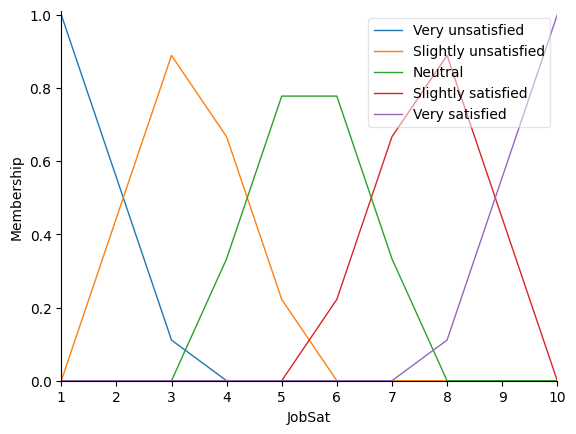

In [102]:
ConvertedCompYearly.view()
WorkExp.view()
RemoteWork.view()
TechScore.view()
AIScore.view()
dev_profile.view()

JobSat.view()

- Define fuzzy rules

In [103]:
rules = [
    ctrl.Rule(ConvertedCompYearly['good'] & WorkExp['good'] & TechScore['good'] & AIScore['good'], JobSat['Very satisfied']),
    ctrl.Rule(WorkExp['good'] & ConvertedCompYearly['good'] & RemoteWork['good'], JobSat['Very satisfied']),
    ctrl.Rule(dev_profile['good'] & TechScore['good'] & RemoteWork['good'], JobSat['Very satisfied']),

    ctrl.Rule(RemoteWork['good'] & ConvertedCompYearly['average'], JobSat['Slightly satisfied']),
    ctrl.Rule(dev_profile['average'] & TechScore['average'], JobSat['Slightly satisfied']),
    ctrl.Rule(AIScore['good'] & WorkExp['poor'], JobSat['Slightly satisfied']),

    ctrl.Rule(ConvertedCompYearly['average'] & WorkExp['average'] & TechScore['average'], JobSat['Neutral']),
    ctrl.Rule(AIScore['average'] & RemoteWork['average'], JobSat['Neutral']),
    ctrl.Rule(ConvertedCompYearly['good'] & TechScore['poor'], JobSat['Neutral']),

    ctrl.Rule(RemoteWork['poor'] & WorkExp['good'], JobSat['Slightly unsatisfied']),
    ctrl.Rule(ConvertedCompYearly['poor'] & TechScore['average'], JobSat['Slightly unsatisfied']),
    ctrl.Rule(AIScore['poor'] & WorkExp['average'], JobSat['Slightly unsatisfied']),

    ctrl.Rule(ConvertedCompYearly['poor'] & WorkExp['poor'], JobSat['Very unsatisfied']),
    ctrl.Rule(TechScore['poor'] & AIScore['poor'], JobSat['Very unsatisfied']),
    ctrl.Rule(dev_profile['poor'], JobSat['Very unsatisfied']),
]

sat_ctrl = ctrl.ControlSystem(rules)

fuzzy simulator

In [104]:
leadership_simulator = ctrl.ControlSystemSimulation(sat_ctrl)

Test case

In [105]:
sample = df.iloc[10]

# Input data to the simulator
leadership_simulator.input['ConvertedCompYearly'] = float(sample.get('ConvertedCompYearly', 0))
leadership_simulator.input['WorkExp'] = float(sample.get('WorkExp', 0))
leadership_simulator.input['RemoteWork'] = float(sample.get('RemoteWork', 0))
leadership_simulator.input['TechScore'] = float(sample.get('TechScore', 0))
leadership_simulator.input['AIScore'] = float(sample.get('AIScore', 0))
leadership_simulator.input['dev_profile'] = float(sample.get('Cluster', 0))

# Compute
leadership_simulator.compute()
pred_score = leadership_simulator.output['JobSat']

def get_label(score):
    if score <= 2:
        return 'Very unsatisfied'
    elif score <= 4:
        return 'Slightly unsatisfied'
    elif score <= 6:
        return 'Neutral'
    elif score <= 8:
        return 'Slightly satisfied'
    else:
        return 'Very satisfied'

pred_label = get_label(pred_score)

print(f"Candidate ID:      {sample.name}")
print(f"Fuzzy Prediction:  {pred_label} ({round(pred_score, 2)})")

Candidate ID:      25
Fuzzy Prediction:  Slightly satisfied (6.38)


# Task 6: Genetic Algorithm Optimization

In [106]:
df['JobSat'].unique()

array([10.,  9.,  8.,  6.,  7.,  3.,  5.,  2.,  4.,  1.,  0.])

In [107]:
df['RemoteWork'].unique()

array([3, 0, 4, 1, 2])

In [108]:
print('dev_profile' in df.columns)
print('Cluster' in df.columns)

False
True


In [109]:
import random

In [110]:
def fitness(chromosome):
    work_exp, salary, tech_score, ai_score, remote_work, cluster = chromosome

    try:
        leadership_simulator.input['WorkExp']              = float(np.clip(work_exp, 0, 1))
        leadership_simulator.input['ConvertedCompYearly']  = float(np.clip(salary, 0, 1))
        leadership_simulator.input['TechScore']            = float(np.clip(tech_score, df['TechScore'].min(), df['TechScore'].max()))
        leadership_simulator.input['AIScore']              = float(np.clip(ai_score, df['AIScore'].min(), df['AIScore'].max()))
        leadership_simulator.input['RemoteWork']           = float(np.clip(round(remote_work), 0, 4))
        leadership_simulator.input['dev_profile']          = float(np.clip(round(cluster), 0, 4))

        leadership_simulator.compute()
        return leadership_simulator.output['JobSat']
    except:
        return 0.0

In [111]:
def create_individual():
    
    return [
        random.uniform(0, 1),                           # WorkExp (scaled 0-1)
        random.uniform(0, 1),                           # Salary (scaled 0-1)
        random.uniform(df['TechScore'].min(), df['TechScore'].max()),  # TechScore
        random.uniform(df['AIScore'].min(), df['AIScore'].max()),      # AIScore
        random.randint(0, 4),                           # RemoteWork (0-4)
        random.randint(0, 4)                            # Cluster (0-4)
    ]


In [112]:
def create_population(size=100):
    return [create_individual() for _ in range(size)]

In [113]:
def tournament_selection(population, fitnesses, k=3):
    selected_idx = random.sample(range(len(population)), k)
    best_idx = max(selected_idx, key=lambda i: fitnesses[i])
    return population[best_idx]

In [114]:
def crossover(parent1, parent2):
    point = random.randint(1, len(parent1) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2


In [115]:
def mutate(chromosome, mutation_rate=0.1):
    mutated = chromosome.copy()
    for i in range(len(mutated)):
        if random.random() < mutation_rate:
            if i == 0:   mutated[i] = random.uniform(0, 1)
            elif i == 1: mutated[i] = random.uniform(0, 1)
            elif i == 2: mutated[i] = random.uniform(df['TechScore'].min(), df['TechScore'].max())
            elif i == 3: mutated[i] = random.uniform(df['AIScore'].min(), df['AIScore'].max())
            elif i == 4: mutated[i] = random.randint(0, 4)
            elif i == 5: mutated[i] = random.randint(0, 4)
    return mutated


In [116]:
def genetic_algorithm(population_size=100, generations=50, mutation_rate=0.1):
    
    # Initialize
    population = create_population(population_size)
    best_fitness_history = []
    avg_fitness_history  = []

    print(f"{'Generation':>10} | {'Best JobSat':>11} | {'Avg JobSat':>10}")
    print("-" * 38)

    for gen in range(generations):
        
        # Evaluate fitness for all individuals
        fitnesses = [fitness(ind) for ind in population]

        # Track best and average
        best_fitness = max(fitnesses)
        avg_fitness  = sum(fitnesses) / len(fitnesses)
        best_fitness_history.append(best_fitness)
        avg_fitness_history.append(avg_fitness)

        if gen % 10 == 0:
            print(f"{gen:>10} | {best_fitness:>11.4f} | {avg_fitness:>10.4f}")
        new_population = []


        elite_indices = sorted(range(len(fitnesses)), key=lambda i: fitnesses[i], reverse=True)[:2]
        for idx in elite_indices:
            new_population.append(population[idx])


        while len(new_population) < population_size:
            parent1 = tournament_selection(population, fitnesses)
            parent2 = tournament_selection(population, fitnesses)
            child1, child2 = crossover(parent1, parent2)
            child1 = mutate(child1, mutation_rate)
            child2 = mutate(child2, mutation_rate)
            new_population.extend([child1, child2])

        population = new_population[:population_size]

    final_fitnesses = [fitness(ind) for ind in population]
    best_idx        = final_fitnesses.index(max(final_fitnesses))
    best_individual = population[best_idx]
    best_score      = final_fitnesses[best_idx]

    return best_individual, best_score, best_fitness_history, avg_fitness_history


In [117]:
best_individual, best_score, best_history, avg_history = genetic_algorithm(
    population_size=100,
    generations=50,
    mutation_rate=0.1
)

Generation | Best JobSat | Avg JobSat
--------------------------------------
         0 |      6.9823 |     5.2215
        10 |      9.1069 |     8.3857
        20 |      9.1069 |     7.9637
        30 |      9.1069 |     7.8364
        40 |      9.1374 |     8.2237


In [118]:
feature_names = ['WorkExp', 'ConvertedCompYearly', 'TechScore', 'AIScore', 'RemoteWork', 'Cluster']

print("\n" + "="*45)
print("BEST SOLUTION FOUND")
print("="*45)
for name, val in zip(feature_names, best_individual):
    print(f"  {name:25} = {val:.4f}")
print(f"\n  Predicted JobSat (Fuzzy) = {best_score:.4f}")
baseline_population = create_population(100)
baseline_fitnesses  = [fitness(ind) for ind in baseline_population]
baseline_best       = max(baseline_fitnesses)
baseline_avg        = sum(baseline_fitnesses) / len(baseline_fitnesses)


BEST SOLUTION FOUND
  WorkExp                   = 0.8710
  ConvertedCompYearly       = 0.9956
  TechScore                 = 1.5048
  AIScore                   = 0.7948
  RemoteWork                = 4.0000
  Cluster                   = 4.0000

  Predicted JobSat (Fuzzy) = 9.1374


In [119]:
print("\n" + "="*45)
print("COMPARISON: GA vs Baseline")
print("="*45)
print(f"  Baseline best JobSat  = {baseline_best:.4f}")
print(f"  Baseline avg  JobSat  = {baseline_avg:.4f}")
print(f"  GA best JobSat        = {best_score:.4f}")
print(f"  Improvement           = +{best_score - baseline_best:.4f}")


COMPARISON: GA vs Baseline
  Baseline best JobSat  = 7.7783
  Baseline avg  JobSat  = 5.2099
  GA best JobSat        = 9.1374
  Improvement           = +1.3591


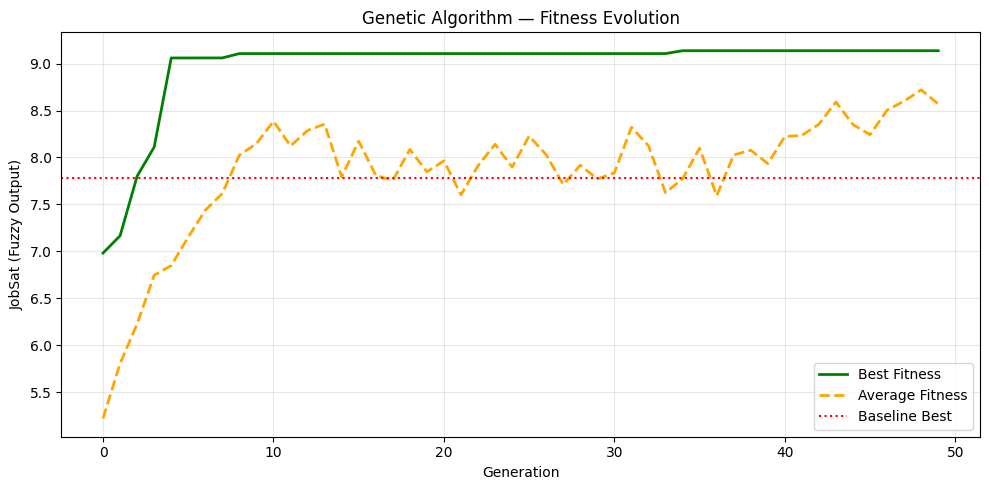

In [120]:
plt.figure(figsize=(10, 5))
plt.plot(best_history, label='Best Fitness',    color='green',  linewidth=2)
plt.plot(avg_history,  label='Average Fitness', color='orange', linewidth=2, linestyle='--')
plt.axhline(y=baseline_best, color='red', linestyle=':', linewidth=1.5, label='Baseline Best')
plt.title('Genetic Algorithm — Fitness Evolution')
plt.xlabel('Generation')
plt.ylabel('JobSat (Fuzzy Output)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [121]:
plt.show()
print("=" * 50)
print("Cluster Sizes:")
print(df['Cluster'].value_counts().sort_index())


Cluster Sizes:
Cluster
0    1423
1    1622
2    2584
3    2543
4    1580
Name: count, dtype: int64


In [122]:
profile_cols = ['JobSat', 'WorkExp', 'ConvertedCompYearly', 
                'TechScore', 'AIScore', 'RemoteWork']

cluster_profiles = df.groupby('Cluster')[profile_cols].mean().round(3)

grand_mean = df[profile_cols].mean().round(3)
print("\nGrand Mean (Overall Average):")
print(grand_mean)

print("\nCluster Profiles (vs Grand Mean):")
diff = cluster_profiles - grand_mean
print(diff.round(3))

print("\nCluster Profiles (Raw Averages):")
print(cluster_profiles)


Grand Mean (Overall Average):
JobSat                 7.177
WorkExp                0.196
ConvertedCompYearly    0.363
TechScore             -0.000
AIScore                0.000
RemoteWork             2.150
dtype: float64

Cluster Profiles (vs Grand Mean):
         JobSat  WorkExp  ConvertedCompYearly  TechScore  AIScore  RemoteWork
Cluster                                                                      
0        -1.403   -0.050               -0.095     -0.042    0.129       0.223
1         0.104    0.026               -0.020     -0.052   -0.000       0.111
2         0.755   -0.041                0.010      0.108    0.197      -0.492
3        -0.209    0.069                0.109     -0.071   -0.313       0.185
4         0.257   -0.024               -0.088      0.029    0.065       0.189

Cluster Profiles (Raw Averages):
         JobSat  WorkExp  ConvertedCompYearly  TechScore  AIScore  RemoteWork
Cluster                                                                      
0        

In [123]:
cluster_names = {
    0: 'Dissatisfied Experienced',
    1: 'Stable Mid-Level',
    2: 'AI Enthusiast',
    3: 'Thriving Senior',
    4: 'Struggling In-Person'
}

df['Cluster_Label'] = df['Cluster'].map(cluster_names)
print(df['Cluster_Label'].value_counts())

Cluster_Label
AI Enthusiast               2584
Thriving Senior             2543
Stable Mid-Level            1622
Struggling In-Person        1580
Dissatisfied Experienced    1423
Name: count, dtype: int64
